# Electrocardiogram (ECG) Heartbeat Categorisation

## Loading Libraries

In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.preprocessing import StandardScaler
from keras.utils import to_categorical
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten, GlobalAveragePooling1D
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import f1_score
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score, precision_score, recall_score, roc_auc_score, ConfusionMatrixDisplay)
from sklearn.utils import shuffle
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import GridSearchCV, KFold, StratifiedKFold, cross_val_score
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings("ignore")


## Reading and Displaying the data

In [5]:
# Loading the datasets. They are already separated into Training data and testing data.
Train_data = pd.read_csv('mitbih_train.csv', header=None)
Test_data = pd.read_csv('mitbih_test.csv', header=None)
# Data inspection to check the rows and colmuns.
print(f"Training Data Shape: {Train_data.shape}")
display(Train_data)


print("--"*35)

print(f"Testing Data Shape: {Test_data.shape}")
display(Test_data)

Training Data Shape: (87554, 188)


,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,0.977941,0.926471,0.681373,0.245098,0.154412,0.191176,0.151961,0.085784,0.058824,0.049020,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.960114,0.863248,0.461538,0.196581,0.094017,0.125356,0.099715,0.088319,0.074074,0.082621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.000000,0.659459,0.186486,0.070270,0.070270,0.059459,0.056757,0.043243,0.054054,0.045946,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.925414,0.665746,0.541436,0.276243,0.196133,0.077348,0.071823,0.060773,0.066298,0.058011,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.967136,1.000000,0.830986,0.586854,0.356808,0.248826,0.145540,0.089202,0.117371,0.150235,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
87549,0.807018,0.494737,0.536842,0.529825,0.491228,0.484211,0.456140,0.396491,0.284211,0.136842,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
87550,0.718333,0.605000,0.486667,0.361667,0.231667,0.120000,0.051667,0.001667,0.000000,0.013333,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
87551,0.906122,0.624490,0.595918,0.575510,0.530612,0.481633,0.444898,0.387755,0.322449,0.191837,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
87552,0.858228,0.645570,0.845570,0.248101,0.167089,0.131646,0.121519,0.121519,0.118987,0.103797,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0


----------------------------------------------------------------------
Testing Data Shape: (21892, 188)


,0,1,2,3,4,5,6,7,8,9,...,178,179,180,181,182,183,184,185,186,187
0,1.000000,0.758264,0.111570,0.000000,0.080579,0.078512,0.066116,0.049587,0.047521,0.035124,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.908425,0.783883,0.531136,0.362637,0.366300,0.344322,0.333333,0.307692,0.296703,0.300366,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.730088,0.212389,0.000000,0.119469,0.101770,0.101770,0.110619,0.123894,0.115044,0.132743,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.000000,0.910417,0.681250,0.472917,0.229167,0.068750,0.000000,0.004167,0.014583,0.054167,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.570470,0.399329,0.238255,0.147651,0.000000,0.003356,0.040268,0.080537,0.070470,0.090604,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21887,0.928736,0.871264,0.804598,0.742529,0.650575,0.535632,0.394253,0.250575,0.140230,0.102299,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
21888,0.802691,0.692078,0.587444,0.446936,0.318386,0.189836,0.118087,0.077728,0.112108,0.152466,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
21889,1.000000,0.967359,0.620178,0.347181,0.139466,0.089021,0.103858,0.100890,0.106825,0.100890,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0
21890,0.984127,0.567460,0.607143,0.583333,0.607143,0.575397,0.575397,0.488095,0.392857,0.238095,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0


## Missing Values Check

In [6]:
# Checking for qunatity of labels for the dataset.
print(f"Training class labels Counts: {Train_data[187].value_counts(ascending=False).sort_index()}")

print("--"*35)

print(f"Testing class labels Counts: {Test_data[187].value_counts(ascending=False).sort_index()}")


Training class labels Counts: 187
0.0    72471
1.0     2223
2.0     5788
3.0      641
4.0     6431
Name: count, dtype: int64
----------------------------------------------------------------------
Testing class labels Counts: 187
0.0    18118
1.0      556
2.0     1448
3.0      162
4.0     1608
Name: count, dtype: int64


In [7]:
# Checking for any missing values.
print("Missing values per column for training data:\n", Train_data.isnull().sum())

print("--"*35)

print("Missing values per column for testing data:\n", Test_data.isnull().sum())

Missing values per column for training data:
 0      0
1      0
2      0
3      0
4      0
      ..
183    0
184    0
185    0
186    0
187    0
Length: 188, dtype: int64
----------------------------------------------------------------------
Missing values per column for testing data:
 0      0
1      0
2      0
3      0
4      0
      ..
183    0
184    0
185    0
186    0
187    0
Length: 188, dtype: int64


In [8]:
# Seprating the training data and the labels.
# This is to prevent the models from seeing the lables before testing.
X_train = Train_data.drop(187, axis=1)
y_train = Train_data[187]

X_test = Test_data.drop(187, axis=1)
y_test = Test_data[187]


In [9]:
# I noticed that the training data is ordered ascendently by class.
# This means that validation set will only get the last 20% and not notice all classes.
# Therfore, I used the shuffle function to avoid overfitting.

X_train, y_train = shuffle(X_train, y_train, random_state=5)


In [10]:
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=5, stratify=y_train)
# Spliting the validation set manually for better class proportions.



print("Checking the labels' porporations")
print(Counter(y_val))


Checking the labels' porporations
Counter({0.0: 14494, 4.0: 1286, 2.0: 1158, 1.0: 445, 3.0: 128})


## Data standardizing


In [11]:
# Standardizing features so all features are learned on the same scale.
# This is because huge nmerical features can dominate when training an MLP model.
scaler =  StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled =  scaler.transform(X_test)
X_val_scaled =  scaler.transform(X_val)


display(X_train_scaled)

print("--"*35)

display(X_test_scaled)

print("--"*35)

display(X_val_scaled)

array([[ 0.43260742,  1.09180041,  0.1223021 , ..., -0.09298482,
        -0.08980142, -0.0876947 ],
       [ 0.45553026, -0.00272267, -1.33538196, ..., -0.09298482,
        -0.08980142, -0.0876947 ],
       [ 0.25929258,  0.47251958,  0.02977225, ..., -0.09298482,
        -0.08980142, -0.0876947 ],
       ...,
       [ 0.45553026, -0.37190649, -1.65296234, ..., -0.09298482,
        -0.08980142, -0.0876947 ],
       [ 0.45553026,  0.88691161, -0.34016609, ..., -0.09298482,
        -0.08980142, -0.0876947 ],
       [ 0.45553026,  0.0859831 , -1.85506308, ..., -0.09298482,
        -0.08980142, -0.0876947 ]])

----------------------------------------------------------------------


array([[ 4.55530261e-01,  2.16499489e-03, -1.37295500e+00, ...,
        -9.29848182e-02, -8.98014177e-02, -8.76947031e-02],
       [ 7.55829236e-02,  1.17640880e-01,  4.74243131e-01, ...,
        -9.29848182e-02, -8.98014177e-02, -8.76947031e-02],
       [-6.64339462e-01, -2.45839540e+00, -1.86415946e+00, ...,
        -9.29848182e-02, -8.98014177e-02, -8.76947031e-02],
       ...,
       [ 4.55530261e-01,  9.44669701e-01,  8.66265795e-01, ...,
        -9.29848182e-02, -8.98014177e-02, -8.76947031e-02],
       [ 3.89672723e-01, -8.57894780e-01,  8.08876502e-01, ...,
        -9.29848182e-02, -8.98014177e-02, -8.76947031e-02],
       [ 3.47529636e-01,  7.00689535e-01,  1.94637479e+00, ...,
        -9.29848182e-02, -8.98014177e-02, -8.76947031e-02]])

----------------------------------------------------------------------


array([[ 0.45553026, -0.96183339, -1.09922073, ..., -0.09298482,
        -0.08980142, -0.0876947 ],
       [ 0.45553026,  0.10182395,  0.04914055, ..., -0.09298482,
        -0.08980142, -0.0876947 ],
       [ 0.45553026,  0.81404641,  0.9882601 , ..., -0.09298482,
        -0.08980142, -0.0876947 ],
       ...,
       [ 0.45553026,  0.31096474,  0.45849699, ..., -0.09298482,
        -0.08980142, -0.0876947 ],
       [ 0.45553026,  0.90645689,  1.05404257, ..., -0.09298482,
        -0.08980142, -0.0876947 ],
       [ 0.39218629, -0.1882067 , -0.4929532 , ..., -0.09298482,
        -0.08980142, -0.0876947 ]])

## Data type checking

In [12]:
print(X_train_scaled.dtype)
print(y_train.dtypes)

print("--"*35)

print(X_test_scaled.dtype)
print(y_test.dtypes)

print("--"*35)

print(X_val_scaled.dtype)
print(y_val.dtypes)

float64
float64
----------------------------------------------------------------------
float64
float64
----------------------------------------------------------------------
float64
float64


In [13]:
# We convert the data type to float32 becuase tensorflow is more optimized for it.
X_train_scaled = X_train_scaled.astype('float32')
y_train = y_train.astype('float32')

X_test_scaled =  X_test.astype('float32')
y_test = y_test.astype('float32')


X_test_scaled =  X_test.astype('float32')
y_test = y_test.astype('float32')

X_val_scaled =  X_val.astype('float32')
y_val = y_val.astype('float32')



['Class 0', 'Class 1', 'Class 2', 'Class 3', 'Class 4']
{0: np.float64(0.2416234023837039), 1: np.float64(7.878852643419573), 2: np.float64(3.0256155507559397), 3: np.float64(27.307212475633527), 4: np.float64(2.722759961127308)}
----------------------------------------------------------------------


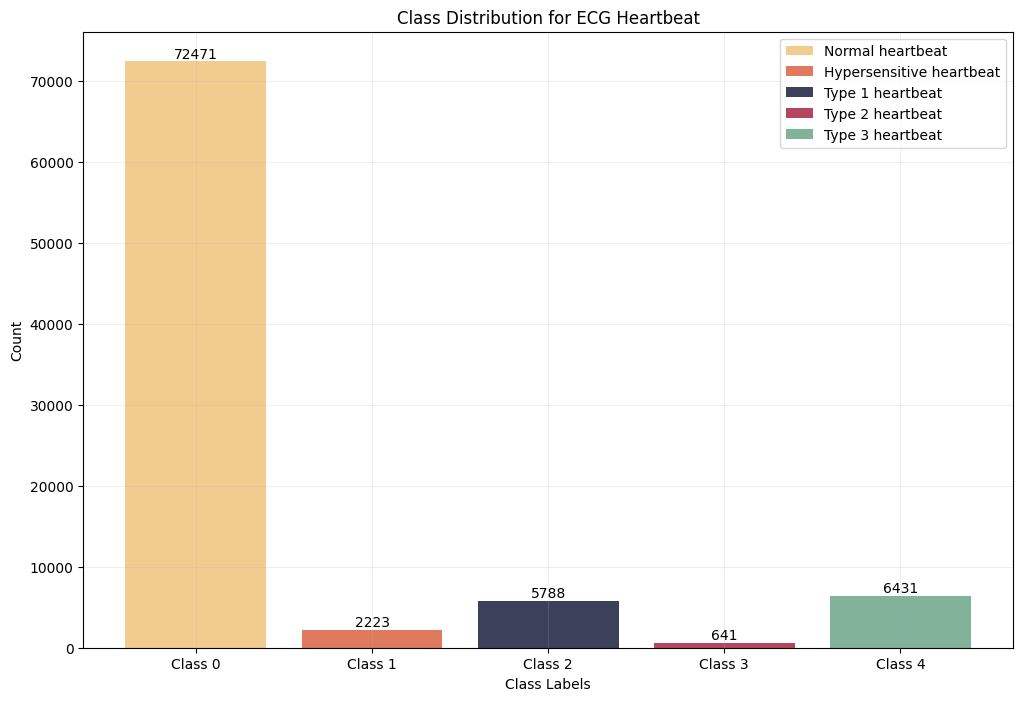

In [16]:
# Based on cell number [6], I also noticed that class 0 is highly dominant which can make the training baised,
# Therfore, I'll use compute_class_weight function to balance the classes.

class_names = ["Class 0", "Class 1", "Class 2", "Class 3", "Class 4"]
lables = ['Normal heartbeat', 'Hypersensitive heartbeat', 'Type 1 heartbeat', 'Type 2 heartbeat', 'Type 3 heartbeat']
auto_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
auto_weights = dict(enumerate(auto_weights))

print(class_names)
print(auto_weights)

counts = Train_data[187].value_counts(ascending=False).sort_index()
colors = ['#f2cc8f', '#e07a5f', '#3d405b', '#b6465f', '#81b29a'] # Source: https://coolors.co/palettes


plt.figure(figsize=(12,8))
bars = plt.bar(class_names, counts, color=colors, label=lables)


print("--"*35)
plt.bar_label(bars, fmt='%d')
plt.xlabel("Class Labels")
plt.ylabel("Count")
plt.title("Class Distribution for ECG Heartbeat")
plt.grid(alpha = 0.2)

plt.xticks(range(len(counts)))
plt.legend()
plt.savefig("barplot.png")

plt.show()


## Apply one-hot encoding

In [17]:
# Converting the targets to one-Hot Encoding.
# This can help improve the model performance and reduce label confusion.

y_train_encoded = to_categorical(y_train, num_classes=5)
y_test_encoded = to_categorical(y_test, num_classes=5)
y_val_encoded = to_categorical(y_val, num_classes=5)


print(y_train_encoded)
print(y_train_encoded.shape)

print("--"*35)

print(y_test_encoded)
print(y_test_encoded.shape)

print("--"*35)

print(y_val_encoded)
print(y_val_encoded.shape)

[[1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 ...
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]]
(70043, 5)
----------------------------------------------------------------------
[[1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 ...
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]]
(21892, 5)
----------------------------------------------------------------------
[[1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 ...
 [1. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [1. 0. 0. 0. 0.]]
(17511, 5)


## Data final check

In [18]:
print("Preprocessing has been Completed:\n")
print(f"Training Dataset: {X_train.shape[0]}")
print(f"Validation Dataset: {X_val.shape[0]}")
print(f"Testing Dataset: {X_test.shape[0]}")
print(f"Feature Dimension: {X_train.shape[1]}")
print(X_train.shape)
print(X_test.shape)
print(X_val.shape)
print(y_train.shape)
print(y_test.shape)
print(y_val.shape)

Preprocessing has been Completed:

Training Dataset: 70043
Validation Dataset: 17511
Testing Dataset: 21892
Feature Dimension: 187
(70043, 187)
(21892, 187)
(17511, 187)
(70043,)
(21892,)
(17511,)


In [24]:
def mlp_model(units=(256,128,64,32), activation='relu', dropout= (0.2, 0, 0.1, 0.2), lr=0.001):

  """
Bulding a Multi-layer Perceptron (MLP).

Parameters
----------
units :        Hidden layers.
activation :   Activation function Rectified Linear Unit (Relu) for non-linearity.
dropout :      Dropout to switch some hidden layers on and off to reduce overfitting.
optimizer :    Optimizer to refine the weights.

lr :           Learning rate for the optimizer for training for efficiency.

Returns
-------
model          Compiled MLP classification model.
  """

  model = Sequential()
  # A simple function to create a neural network layer by layer.
  model.add(Dense(units[0], activation=activation, input_shape=(X_train_scaled.shape[1],)))
  model.add(Dropout(dropout[0]))
  model.add(Dense(units[1], activation=activation,kernel_regularizer=regularizers.l2(0.001)))
  model.add(Dropout(dropout[1]))
  for unit, drop in zip(units[2:], dropout[2:]):
      model.add(Dense(unit, activation=activation))
      model.add(Dropout(drop))
  model.add(Dense(5, activation='softmax'))
  # Using softmax for multi-class classification tasks.
  optimizer = Adam(learning_rate=lr)
  model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
  # Using categorical_crossentropy to predict the correct class in multi-class classification tasks.
  return model

# **Model 1**: Training on **MLP** Model


# Training the model after using computing different class weights

In [49]:
callback = EarlyStopping(monitor='val_loss',restore_best_weights= True, patience=3)
# Using Early stopping to stop the training when the performance of the model on a validation dataset stops improving.


print("Training auto-weights MLP model...")
base_model = mlp_model()
base_model.fit(X_train_scaled, y_train_encoded, validation_data=(X_val_scaled, y_val_encoded), epochs=30, batch_size=32, class_weight=auto_weights,
               callbacks=[callback] ,verbose=1)
# Epochs means how many complete passes for the training data.
# Batch size is How many data being passed in each epach.

p_y_pred = base_model.predict(X_test_scaled)
y_pred = np.argmax(p_y_pred, axis= 1)
# Using np.argmax to return the highest probability of the predicted class.


print("Baseline MLP Model Performance:")
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Training auto-weights MLP model...
Epoch 1/30
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.6557 - loss: 0.8410 - val_accuracy: 0.8952 - val_loss: 1.0471
Epoch 2/30
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7640 - loss: 0.6062 - val_accuracy: 0.8544 - val_loss: 0.9627
Epoch 3/30
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8007 - loss: 0.5252 - val_accuracy: 0.9194 - val_loss: 0.7644
Epoch 4/30
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8179 - loss: 0.4760 - val_accuracy: 0.9021 - val_loss: 0.6903
Epoch 5/30
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8366 - loss: 0.4326 - val_accuracy: 0.9009 - val_loss: 0.6596
Epoch 6/30
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8366 - loss: 0.4096 - val_accuracy: 0.8772 - val_loss: 0.6320
Epoch 7/30
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8543 - loss: 0.3751 - val_accuracy: 0.8917 - val_loss: 0.6904
Epoch 8/30
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step 

# **Model 2**: Training on **MLP** Model (Manual Weights)

In [50]:
manual_weights = {0: 1, 1: 15, 2: 5, 3: 50, 4: 5}

In [51]:
callback = EarlyStopping(monitor='val_loss',restore_best_weights= True, patience=3)
# Using Early stopping to stop the training when the performance of the model on a validation dataset stops improving.


print("Training Manual Weights MLP model...")
mlp = mlp_model()
mlp.fit(X_train_scaled, y_train_encoded, validation_data=(X_val_scaled, y_val_encoded), epochs=30, batch_size=32, class_weight=manual_weights,
               callbacks=[callback] ,verbose=1)
# Epochs means how many complete passes for the training data.
# Batch size is How many data being passed in each epach.

p_y_pred = mlp.predict(X_test_scaled)
y_pred = np.argmax(p_y_pred, axis= 1)
# Using np.argmax to return the highest probability of the predicted class.


print("Baseline MLP Model Performance:")
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Training Manual Weights MLP model...
Epoch 1/30
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.8240 - loss: 1.6862 - val_accuracy: 0.8692 - val_loss: 0.8239
Epoch 2/30
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8766 - loss: 1.2362 - val_accuracy: 0.9188 - val_loss: 0.7344
Epoch 3/30
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8929 - loss: 1.0707 - val_accuracy: 0.9190 - val_loss: 0.8010
Epoch 4/30
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9041 - loss: 0.9826 - val_accuracy: 0.9149 - val_loss: 0.6791
Epoch 5/30
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9131 - loss: 0.9172 - val_accuracy: 0.9139 - val_loss: 0.6506
Epoch 6/30
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9148 - loss: 0.8444 - val_accuracy: 0.9065 - val_loss: 0.6132
Epoch 7/30
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9189 - loss: 0.7914 - val_accuracy: 0.9101 - val_loss: 0.5269
Epoch 8/30
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/ste

# **Model 3**: Training on **MLP** Model (SMOTE)

In [21]:
# Since the dataset is highly imbalanced, using SMOTE to help create
# synthetic data for class 3 since it's the lowest.

print("Class distribution before SMOTE:", Counter(y_train))
smote = SMOTE(sampling_strategy={3: 2000}, random_state=5, k_neighbors=3)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print("Class distribution after SMOTE:", Counter(y_train_sm))
y_train_sm_encoded = to_categorical(y_train_sm)

Class distribution before SMOTE: Counter({0.0: 57977, 4.0: 5145, 2.0: 4630, 1.0: 1778, 3.0: 513})
Class distribution after SMOTE: Counter({0.0: 57977, 4.0: 5145, 2.0: 4630, 3.0: 2000, 1.0: 1778})


In [26]:
callback = EarlyStopping(monitor='val_loss',restore_best_weights= True, patience=3)

SMOTE_weights = {0: 1, 1: 10, 2: 5, 3: 40, 4: 5}

print("Training SMOTE MLP model...")
SMOTE_model = mlp_model()
SMOTE_model.fit(X_train_sm, y_train_sm_encoded, validation_data=(X_val_scaled, y_val_encoded), epochs=30, batch_size=32, class_weight=SMOTE_weights,
               callbacks=[callback] ,verbose=1)

p_y_pred = SMOTE_model.predict(X_test_scaled)
y_pred = np.argmax(p_y_pred, axis= 1)

SMOTE_model.save("final_mlp_model.h5")


print("SMOTE Model Performance:")
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Training SMOTE MLP model...
Epoch 1/30
2236/2236 ━━━━━━━━━━━━━━━━━━━━ 15s 5ms/step - accuracy: 0.7939 - loss: 1.8094 - val_accuracy: 0.8942 - val_loss: 0.4406
Epoch 2/30
2236/2236 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8538 - loss: 1.2711 - val_accuracy: 0.8428 - val_loss: 0.5791
Epoch 3/30
2236/2236 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8749 - loss: 1.0843 - val_accuracy: 0.8782 - val_loss: 0.4622
Epoch 4/30
2236/2236 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8849 - loss: 0.9768 - val_accuracy: 0.9188 - val_loss: 0.3631
Epoch 5/30
2236/2236 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8959 - loss: 0.9193 - val_accuracy: 0.9272 - val_loss: 0.3483
Epoch 6/30
2236/2236 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.9028 - loss: 0.8553 - val_accuracy: 0.8880 - val_loss: 0.4624
Epoch 7/30
2236/2236 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9031 - loss: 0.8219 - val_accuracy: 0.9232 - val_loss: 0.3434
Epoch 8/30
2236/2236 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - acc

SMOTE Model Performance:
Test Accuracy: 0.9528594920518911
              precision    recall  f1-score   support

         0.0       0.99      0.96      0.97     18118
         1.0       0.58      0.73      0.64       556
         2.0       0.88      0.90      0.89      1448
         3.0       0.37      0.91      0.53       162
         4.0       0.96      0.96      0.96      1608

    accuracy                           0.95     21892
   macro avg       0.76      0.89      0.80     21892
weighted avg       0.96      0.95      0.96     21892

[[17456   283   151   177    51]
 [  132   405    10     6     3]
 [   68     7  1303    64     6]
 [   11     1     3   147     0]
 [   37     5    16     1  1549]]


# **Model 4**: Training on **MLP** Model (Under Sample + SMOTE)

In [57]:
# Since the dataset is highly imbalanced, using undersampling to help create
# reduce data for class 0 since it's the highest.

print("Class distribution before undersampling:", Counter(y_train_sm))
Under_sample = RandomUnderSampler(sampling_strategy={0: 30000}, random_state=5, replacement=False)
X_train_under, y_train_under = Under_sample.fit_resample(X_train_sm, y_train_sm)
print("Class distribution after undersampling:", Counter(y_train_under))
y_train_under_encoded = to_categorical(y_train_under)

Class distribution before undersampling: Counter({0.0: 57977, 4.0: 5145, 2.0: 4630, 3.0: 2000, 1.0: 1778})
Class distribution after undersampling: Counter({0.0: 30000, 4.0: 5145, 2.0: 4630, 3.0: 2000, 1.0: 1778})


In [58]:
callback = EarlyStopping(monitor='val_loss',restore_best_weights= True, patience=3)

Under_sample_weights = {0: 1, 1: 10, 2: 5, 3: 40, 4: 5}


print("Training Under Sample MLP model...")
Under_sample_model = mlp_model()
Under_sample_model.fit(X_train_under, y_train_under_encoded, validation_data=(X_val, y_val_encoded), epochs=30, batch_size=32, class_weight=Under_sample_weights,
               callbacks=[callback] ,verbose=1)

p_y_pred = Under_sample_model.predict(X_test_scaled)
y_pred = np.argmax(p_y_pred, axis= 1)



print("Under Sample Model Performance:")
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Training Under Sample MLP model...
Epoch 1/30
1362/1362 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.6592 - loss: 2.7006 - val_accuracy: 0.7055 - val_loss: 1.0239
Epoch 2/30
1362/1362 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7974 - loss: 1.7827 - val_accuracy: 0.8613 - val_loss: 0.5962
Epoch 3/30
1362/1362 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8282 - loss: 1.5307 - val_accuracy: 0.8489 - val_loss: 0.6227
Epoch 4/30
1362/1362 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8444 - loss: 1.3777 - val_accuracy: 0.8424 - val_loss: 0.6063
Epoch 5/30
1362/1362 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8601 - loss: 1.2288 - val_accuracy: 0.9177 - val_loss: 0.3839
Epoch 6/30
1362/1362 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8617 - loss: 1.1756 - val_accuracy: 0.8819 - val_loss: 0.5048
Epoch 7/30
1362/1362 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8747 - loss: 1.0965 - val_accuracy: 0.9128 - val_loss: 0.3761
Epoch 8/30
1362/1362 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step 

# **Model 5**: Training on **CNN** Model

In [63]:
def cnn_model(filters=(256,128), dense=(64,32), activation='relu', dropout= (0.2, 0, 0.1, 0.2), lr=0.001):

  """
Bulding a Convolutional Neural Network (CNN).

Parameters
----------
filters :      Metrics to slide over the data.
units :        Hidden layers.
activation :   Activation function Rectified Linear Unit (Relu) for non-linearity.
dropout :      Dropout to switch some hidden layers on and off to reduce overfitting.
optimizer :    Optimizer to refine the weights.

lr :           Learning rate for the optimizer for training for efficiency.

Returns
-------
model          Compiled CNN classification model.
  """

  model = Sequential()
  model.add(Conv1D(filters[0], kernel_size=5, activation=activation, padding="same", input_shape=(X_train_scaled.shape[1],1)))
  # Conv1D to extract patterns in the data.
  # Kernel size to provide the dimensions of the filter window.
  # Padding to adds extra zeros to preserve information.
  model.add(MaxPooling1D(pool_size=2))
  # MaxPooling1D to reduce the feature map size but keep important data.
  model.add(Dropout(dropout[0]))
  model.add(Conv1D(filters[1], kernel_size=5, activation=activation, padding="same" ,kernel_regularizer=regularizers.l2(0.001)))
  model.add(MaxPooling1D(pool_size=2))
  model.add(Dropout(dropout[1]))
  model.add(GlobalAveragePooling1D())
  # GlobalAveragePooling1D to reduce the features map by taking the average to keep 1 value for each filter.
  for unit in dense:
      model.add(Dense(unit, activation=activation))
      model.add(Dropout(dropout[2]))
  model.add(Dense(5, activation='softmax'))
  optimizer = Adam(learning_rate=lr)
  model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
  return model

In [60]:
# Reshaping the data because CNN expects the data to shape to have the channel number.
# For example in RGB images, it has 3 channels, but here in this case it is 1 since it's a numerical data.
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.values.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)
X_val_cnn = X_val_scaled.values.reshape(X_val_scaled.shape[0], X_val_scaled.shape[1], 1)

In [64]:
callback = EarlyStopping(monitor='val_loss',restore_best_weights= True, patience=3)


print("Training baseline CNN model...")
cnn = cnn_model()
cnn.fit(X_train_cnn, y_train_encoded, validation_data=(X_val_cnn, y_val_encoded), epochs=30, batch_size=32, class_weight=None,
               callbacks=[callback] ,verbose=1)

p_y_pred = cnn.predict(X_test_cnn)
y_pred = np.argmax(p_y_pred, axis= 1)



print(" Baseline CNN Model Performance:")
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Training baseline CNN model...
Epoch 1/30
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 25s 8ms/step - accuracy: 0.8712 - loss: 0.4909 - val_accuracy: 0.8277 - val_loss: 0.9231
Epoch 2/30
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9287 - loss: 0.2987 - val_accuracy: 0.8261 - val_loss: 1.1870
Epoch 3/30
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9409 - loss: 0.2500 - val_accuracy: 0.8277 - val_loss: 1.2200
Epoch 4/30
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9470 - loss: 0.2244 - val_accuracy: 0.8277 - val_loss: 1.0665
685/685 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
 Baseline CNN Model Performance:
Test Accuracy: 0.8276082587246483
              precision    recall  f1-score   support

         0.0       0.83      1.00      0.91     18118
         1.0       0.00      0.00      0.00       556
         2.0       0.00      0.00      0.00      1448
         3.0       0.00      0.00      0.00       162
         4.0       0.00      0.00      0.00      1608

    accurac

From the accuracy metrics, we can see that all models struggle, especially with identifying class 3. Principal Component Analysis PCA may help to investigate this issue further.

Explained variability per principal component: [0.36635378 0.15631744]


<Figure size 640x480 with 0 Axes>

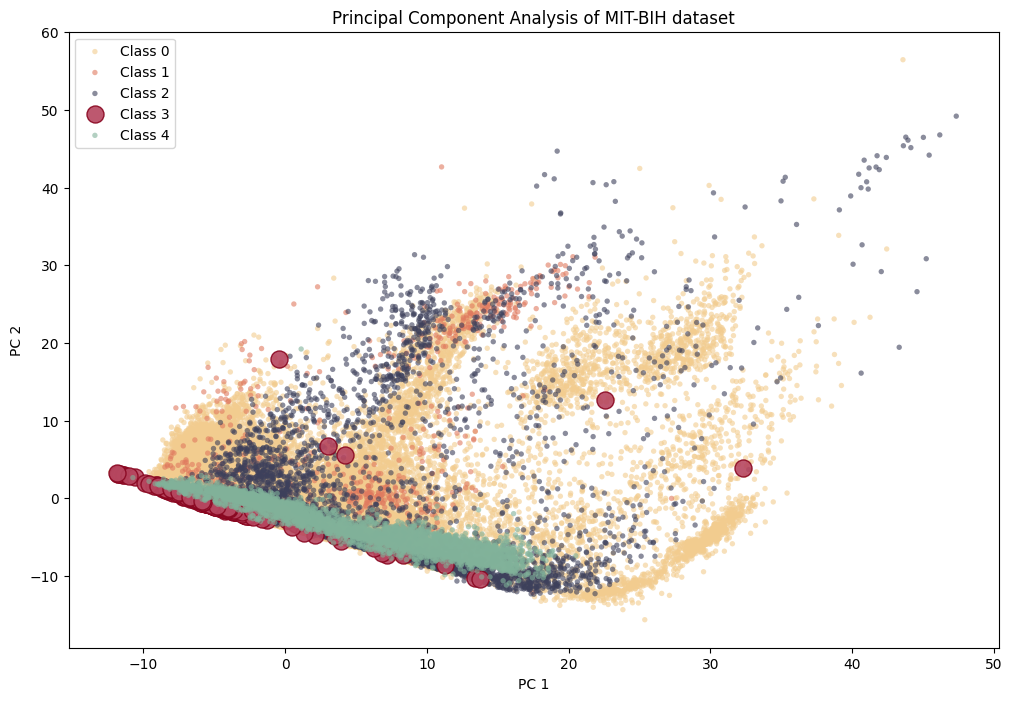

In [73]:
# Appling Principal Component Analysis PCA
# This will reduce the dimentionality of the data features.
# It help to plot the data in order to investivage the class 3 issue
pca_ecg = PCA(n_components=2)
principalComponents_ecg = pca_ecg.fit_transform(X_train_scaled)
principal_ecg_Df = pd.DataFrame(data = principalComponents_ecg
             , columns = ['principal component 1', 'principal component 2'])

principal_ecg_Df['target'] = y_train.values


print('Explained variability per principal component: {}'.format(pca_ecg.explained_variance_ratio_))

plt.figure()
plt.figure(figsize=(12,8))
plt.xticks()
plt.yticks()
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.title("Principal Component Analysis of MIT-BIH dataset")
targets = [0, 1, 2, 3, 4]
colors = ['#f2cc8f', '#e07a5f', '#3d405b', '#b6465f', '#81b29a'] # Source: https://coolors.co/palettes

for target, color in zip(targets,colors):
    indicesToKeep = principal_ecg_Df['target'] == target
    c=colors[target],
    s=150 if target == 3 else 15
    alpha=0.9 if target == 3 else 0.60
    label=f"Class {target}"
    edgecolors='#890620' if target == 3 else 'none'
    plt.scatter(principal_ecg_Df.loc[indicesToKeep, 'principal component 1']
               , principal_ecg_Df.loc[indicesToKeep, 'principal component 2'],c=color, s=s,
        alpha=alpha, edgecolors=edgecolors, label=label
    )


plt.legend()
plt.savefig("PCA.png", dpi=300, bbox_inches='tight')
plt.show()


We can see that the first and second principal components explain 52% of the data's variability, which is a significant amount. It can also be seen that class 3 is overlapping with other classes heavily, which explains why the model is struggling to distinguish it. The plot above shows class 3 (pink color) features are intersecting with other classes.

The best performing model so far was Model 3 with SMOTE, which achieved 95% accuracy and a macro average F1-score of 80%.

Class 0 and Class 4 showed excellent performance, while Class 2 achieved moderate performance. However, Classes 1 and 3 produced the weakest results, with Class 3 being the most difficult class.

This shows a severe class imbalance in the dataset and possible feature overlap features.

Based on the results above, I will conduct a manual grid search for different variations of model 3.

In [74]:

param_grid = {'units': [(256,128,64,32), (256,64,32), (128,32,32), (64,32)],
              'dropout' : [(0.2, 0, 0.1, 0.2), (0.1, 0.2, 0.1, 0.2)],
              'activation' : ['relu', 'tanh'],
              'lr': [0.001, 0.0005]
             }

best_score = 0
best_model = None
best_config = {}


print("Starting Manual Grid Search ...")
for u in param_grid['units']:
    for drop in param_grid['dropout']:
        for activation in param_grid['activation']:
          for lr in param_grid['lr']:
                print(f"Training: units={u}, drop={drop}, activation={activation}  ,lr={lr}")
                model = mlp_model(units=u, dropout=drop, activation=activation,lr=lr)
                hist = model.fit(X_train_sm, y_train_sm_encoded, validation_data=(X_val, y_val_encoded),
                                 callbacks=[callback], epochs=30, batch_size=32, class_weight= SMOTE_weights, verbose=0)

                val_probs = model.predict(X_val, verbose=0)
                val_preds = np.argmax(val_probs, axis=1)
                val_f1 = f1_score(y_val, val_preds, average='macro')
                # Since the dataset is imbalaned, I will choose macro F1 for comparison.
                # F1 balances recall and precsion. It failed when detecting class 3.
                # Using Val accuracy here could be misleading because class 0 is very dominant in the dataset.

                print(f"→ Val macro F1: {val_f1:.4f}")
                print("--"*35)


                if val_f1 > best_score:
                    best_score = val_f1
                    best_model = model
                    best_config = {'units': u, 'dropout': drop,'activation': activation, 'lr': lr}

# Final evaluation
print("Best Hyperparameters Found:")
print(best_config)

p_y_pred = best_model.predict(X_test_scaled)
y_pred = np.argmax(p_y_pred, axis= 1)


print("Final Model Evaluation:")
print("Test Accuracy:", accuracy_score(y_test, y_pred))

Starting Manual Grid Search ...
Training: units=(256, 128, 64, 32), drop=(0.2, 0, 0.1, 0.2), activation=relu  ,lr=0.001
→ Val macro F1: 0.7861
----------------------------------------------------------------------
Training: units=(256, 128, 64, 32), drop=(0.2, 0, 0.1, 0.2), activation=relu  ,lr=0.0005
→ Val macro F1: 0.6643
----------------------------------------------------------------------
Training: units=(256, 128, 64, 32), drop=(0.2, 0, 0.1, 0.2), activation=tanh  ,lr=0.001
→ Val macro F1: 0.6410
----------------------------------------------------------------------
Training: units=(256, 128, 64, 32), drop=(0.2, 0, 0.1, 0.2), activation=tanh  ,lr=0.0005
→ Val macro F1: 0.6445
----------------------------------------------------------------------
Training: units=(256, 128, 64, 32), drop=(0.1, 0.2, 0.1, 0.2), activation=relu  ,lr=0.001
→ Val macro F1: 0.6086
----------------------------------------------------------------------
Training: units=(256, 128, 64, 32), drop=(0.1, 0.2, 0.

In [75]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.98      0.97      0.97     18118
         1.0       0.67      0.65      0.66       556
         2.0       0.91      0.87      0.89      1448
         3.0       0.29      0.86      0.44       162
         4.0       0.95      0.95      0.95      1608

    accuracy                           0.95     21892
   macro avg       0.76      0.86      0.78     21892
weighted avg       0.96      0.95      0.95     21892



In [113]:

kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=15)

# Using stratifiedKFold to keep class proportions similar to one anohter.

histories = []
cv_scores = []

X_np = np.asarray(X_train_scaled)
y_np = np.asarray(y_train).astype(int)

print("Running K-Fold Cross-Validation and Saving Each Fold Model...")
for fold, (train_idx, val_idx) in enumerate(kf.split(X_np, y_np)):
    print(f"\nFold {fold+1}")

    # To split data for each fold individually.
    X_fold_train, X_fold_val = X_np[train_idx], X_np[val_idx]
    y_fold_train, y_fold_val = y_np[train_idx], y_np[val_idx]


    smote = SMOTE(sampling_strategy={3: 2000}, random_state=5, k_neighbors=3)
    X_fold_train, y_fold_train = smote.fit_resample(X_fold_train ,y_fold_train)

    y_fold_train_encoded = to_categorical(y_fold_train, num_classes=5)
    y_fold_val_encoded = to_categorical(y_fold_val, num_classes=5)

    callback = EarlyStopping(monitor='val_loss', restore_best_weights=True, patience=3)

    model = mlp_model(units=(256,128,64,32), activation='relu', dropout= (0.2, 0, 0.1, 0.2), lr=0.001)
    # Best hyperparameters based on the grid search.
    history = model.fit(X_fold_train, y_fold_train_encoded, validation_data=(X_fold_val, y_fold_val_encoded), epochs=30,
                        callbacks=[callback], batch_size=32, class_weight=SMOTE_weights, verbose=0)

    # To save the best fold with best validation fold.
    model_path = f"mlpfold{fold+1}.h5"
    model.save(model_path)
    print(f"Saved: {model_path}")

    # Save accuracy and history
    val_probs = model.predict(X_fold_val)
    val_preds = np.argmax(val_probs, axis=1)
    fold_macro_f1 = f1_score(y_fold_val, val_preds, average="macro")
    fold_weighted_f1 = f1_score(y_fold_val, val_preds, average="weighted")
    acc = accuracy_score(y_fold_val, val_preds)
    cv_scores.append({
    "Fold": fold + 1,
    "Accuracy": acc,
    "Macro F1": fold_macro_f1,
    "Weighted F1": fold_weighted_f1,
    })
    histories.append(history)

    print(f"Fold {fold+1} Accuracy: {acc:.4f}")
    print(f"Fold {fold+1} Macro F1: {fold_macro_f1:.4f}")
    print(f"Fold {fold+1} Weighted F1: {fold_weighted_f1:.4f}")
    print(f"Fold {fold+1} True labels:", Counter(y_fold_val))
    print(f"Fold {fold+1} Predicted labels:", Counter(val_preds))


print("Cross Validation Tabel for all 3 folds:")
cv_scores_df = pd.DataFrame(cv_scores)
display(cv_scores_df)


Running K-Fold Cross-Validation and Saving Each Fold Model...

Fold 1


Saved: mlpfold1.h5
730/730 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
Fold 1 Accuracy: 0.9382
Fold 1 Macro F1: 0.7445
Fold 1 Weighted F1: 0.9443
Fold 1 True labels: Counter({np.int64(0): 19326, np.int64(4): 1715, np.int64(2): 1543, np.int64(1): 593, np.int64(3): 171})
Fold 1 Predicted labels: Counter({np.int64(0): 18710, np.int64(4): 1709, np.int64(2): 1693, np.int64(1): 658, np.int64(3): 578})

Fold 2


Saved: mlpfold2.h5
730/730 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Fold 2 Accuracy: 0.9359
Fold 2 Macro F1: 0.7491
Fold 2 Weighted F1: 0.9442
Fold 2 True labels: Counter({np.int64(0): 19326, np.int64(4): 1715, np.int64(2): 1543, np.int64(1): 593, np.int64(3): 171})
Fold 2 Predicted labels: Counter({np.int64(0): 18707, np.int64(4): 1819, np.int64(2): 1446, np.int64(3): 780, np.int64(1): 596})

Fold 3


Saved: mlpfold3.h5
730/730 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Fold 3 Accuracy: 0.9379
Fold 3 Macro F1: 0.7522
Fold 3 Weighted F1: 0.9456
Fold 3 True labels: Counter({np.int64(0): 19325, np.int64(4): 1715, np.int64(2): 1544, np.int64(1): 592, np.int64(3): 171})
Fold 3 Predicted labels: Counter({np.int64(0): 18618, np.int64(4): 1831, np.int64(2): 1561, np.int64(3): 740, np.int64(1): 597})
Cross Validation Tabel for all 3 folds:


,Fold,Accuracy,Macro F1,Weighted F1
0,1,0.938196,0.744471,0.944291
1,2,0.935926,0.749095,0.944183
2,3,0.937851,0.752186,0.945623


Fold 3 has the best results with 94% accuracy, 75% macro F1 and 94% weighted F1.

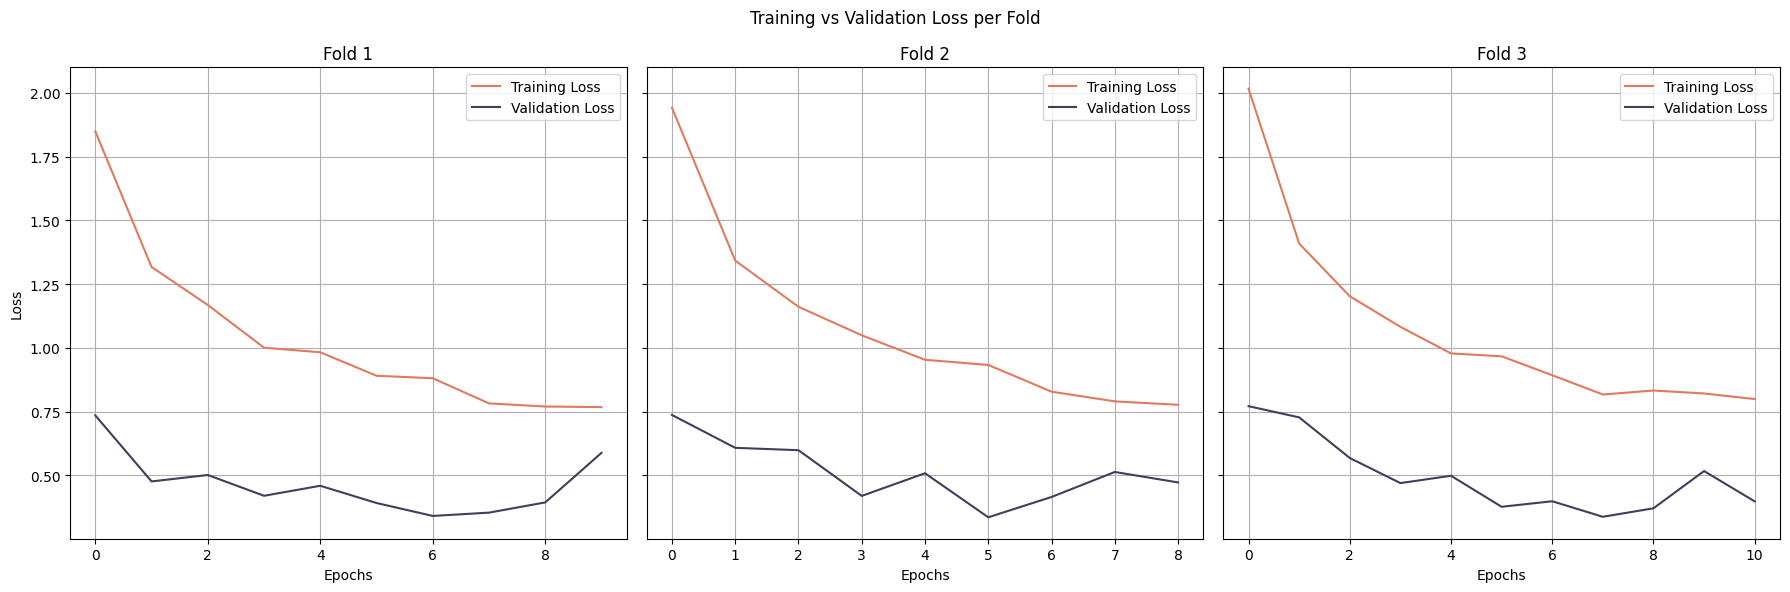

In [114]:
# Plot learning Curves for all folds
fig, axes = plt.subplots(1,3, figsize=(18, 6), sharey=True)

axes = axes.flatten()

for i, history in enumerate(histories):
    axes[i].plot(history.history['loss'], label='Training Loss', color='#e07a5f')
    axes[i].plot(history.history['val_loss'], label='Validation Loss', color='#3d405b')
    axes[i].set_title(f'Fold {i+1}')
    axes[i].set_xlabel('Epochs')
    axes[i].grid(True)
    if i == 0:
        axes[i].set_ylabel('Loss')
    axes[i].legend()

plt.suptitle('Training vs Validation Loss per Fold')
plt.tight_layout()
plt.savefig("kfolds.png", dpi=300, bbox_inches='tight')
plt.show()

In [115]:
# Testing the fold 3 model.
print("Loading Model from Saved Fold...")
model = load_model("mlpfold3.h5")


y_train_pred_probs = model.predict(X_train_scaled)
y_test_pred_probs = model.predict(X_test_scaled)

y_train_pred = np.argmax(y_train_pred_probs, axis=1)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)

def evaluate_model(y_true, y_pred, dataset_label):
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")
    macro_recall = recall_score(y_true, y_pred, average="macro")

    print(f"Evaluation Metrics for {dataset_label}:")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1-score: {macro_f1:.4f}")
    print(f"Weighted F1-score: {weighted_f1:.4f}")
    print(f"Macro Recall: {macro_recall:.4f}")

    ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
    plt.title(f'Confusion Matrix - {dataset_label}')
    plt.savefig("Confusion_Matrix_test.png", dpi=300, bbox_inches='tight')
    plt.show()



print(classification_report(y_test, y_test_pred))

Loading Model from Saved Fold...
2189/2189 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step
685/685 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

         0.0       0.90      0.99      0.94     18118
         1.0       0.50      0.00      0.00       556
         2.0       0.99      0.14      0.24      1448
         3.0       0.00      0.00      0.00       162
         4.0       0.87      0.89      0.88      1608

    accuracy                           0.90     21892
   macro avg       0.65      0.41      0.41     21892
weighted avg       0.89      0.90      0.86     21892



In [29]:
# Testing the best performing model so far.
print("Loading Model from Saved Fold...")
model = load_model("ANN_model.h5")


y_train_pred_probs = model.predict(X_train_sm)
y_test_pred_probs = model.predict(X_test_scaled)

y_train_pred = np.argmax(y_train_pred_probs, axis=1)
y_test_pred = np.argmax(y_test_pred_probs, axis=1)

def evaluate_model(y_true, y_pred, dataset_label):
    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average="macro")
    weighted_f1 = f1_score(y_true, y_pred, average="weighted")
    macro_precision = precision_score(y_true, y_pred, average='macro')

    print(f"Evaluation Metrics for {dataset_label}:")
    print(f"Accuracy: {acc:.4f}")
    print(f"Macro F1-score: {macro_f1:.4f}")
    print(f"Weighted F1-score: {weighted_f1:.4f}")
    print(f"Macro Precision: {macro_precision:.4f}")

    ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
    plt.title(f'Confusion Matrix - {dataset_label}')
    plt.savefig("Confusion_Matrix_test.png", dpi=300, bbox_inches='tight')
    plt.show()



print(classification_report(y_test, y_test_pred))

Loading Model from Saved Fold...
2236/2236 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
685/685 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

         0.0       0.99      0.96      0.97     18118
         1.0       0.58      0.73      0.64       556
         2.0       0.88      0.90      0.89      1448
         3.0       0.37      0.91      0.53       162
         4.0       0.96      0.96      0.96      1608

    accuracy                           0.95     21892
   macro avg       0.76      0.89      0.80     21892
weighted avg       0.96      0.95      0.96     21892



Evaluation Metrics for Training Set:
Accuracy: 0.9593
Macro F1-score: 0.8776
Weighted F1-score: 0.9612
Macro Precision: 0.8388


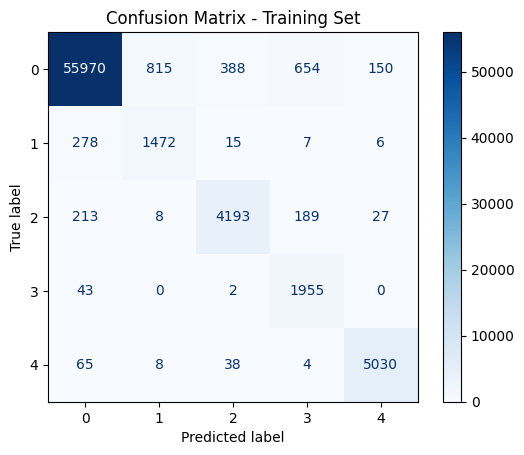

In [30]:
evaluate_model(y_train_sm, y_train_pred, "Training Set")

Evaluation Metrics for Test Set:
Accuracy: 0.9529
Macro F1-score: 0.7998
Weighted F1-score: 0.9564
Macro Precision: 0.7554


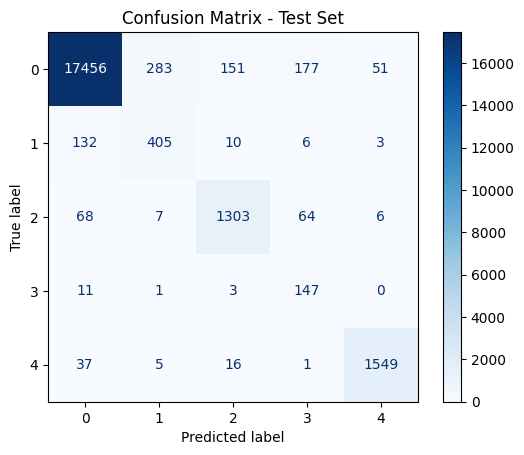

In [31]:
evaluate_model(y_test, y_test_pred, "Test Set")


## Declaration

The code was adapted from Machine Learning (ECMM422_J_3_202526) module (Workshop 1 and 2).

Some analysis ideas were inspired from Applications of Data Science and Statistics (MTHM503_J_3_202526) module.